In [1]:
import numpy as np
import matplotlib.pyplot as plt

building random data and splitting

In [6]:
np.random.seed(42)
time_steps = 1000
t = np.linspace(0, 20 * np.pi, time_steps)
data = np.sin(t) + 0.15 * np.random.randn(time_steps)

train_len = 700
test_len = 300
transient_len = 100

constructing the reservoir

In [8]:
inner_nodes = 200
alpha = 0.3
spectral_radius = 0.9
lambda_reg = 1e-4

input_weights = np.random.uniform(-1, 1, (inner_nodes, 1))
A = np.random.uniform(-1, 1, (inner_nodes, inner_nodes))
eigenvalues = np.linalg.eigvals(A)
max_eigenvalue = np.max(np.abs(eigenvalues))
A = A * (spectral_radius / max_eigenvalue)
b = np.random.uniform(-0.1, 0.1, (inner_nodes, 1))


R = np.zeros((inner_nodes, train_len))
r = np.zeros((inner_nodes, 1))
for i in range(train_len):
    u_i = data[i]
    r = (1 - alpha) * r + alpha * np.tanh(np.dot(A, r) + input_weights * u_i + b)
    R[:, i] = r[:, 0]

running it

In [9]:
X_target = data[1 : train_len + 1].reshape(1, -1)
R_train = R[:, transient_len:]
X_train = X_target[:, transient_len:]

R_RT = np.dot(R_train, R_train.T)
X_RT = np.dot(X_train, R_train.T)
I = np.eye(inner_nodes)
output_weights = np.dot(X_RT, np.linalg.inv(R_RT + lambda_reg * I))
r_test = R[:, -1].reshape(-1, 1) 
predictions = []
for i in range(train_len, train_len + test_len - 1):
    u_i = data[i]
    r_test = (1 - alpha) * r_test + alpha * np.tanh(np.dot(A, r_test) + input_weights * u_i + b)
    pred = np.dot(output_weights, r_test)
    predictions.append(pred[0, 0])

charts

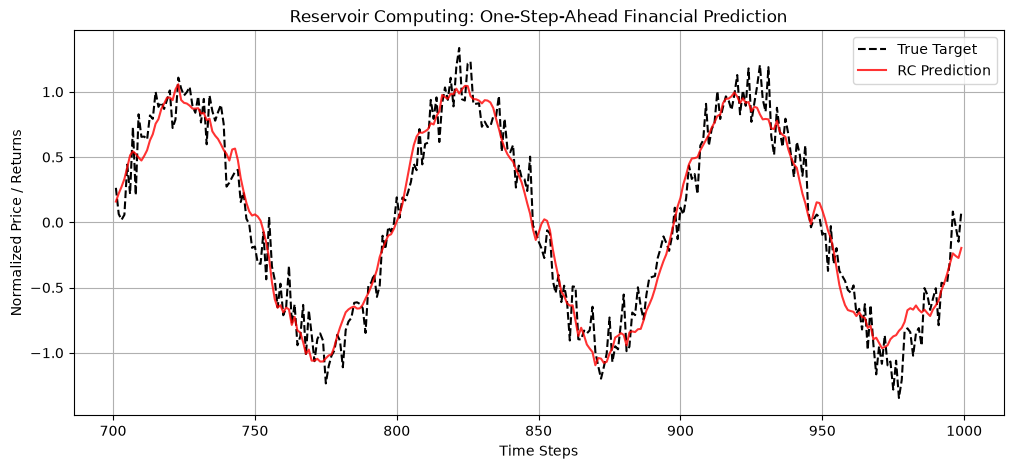

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(range(train_len + 1, time_steps), data[train_len + 1:], label="True Target", color="black", linestyle="dashed")
plt.plot(range(train_len + 1, time_steps), predictions, label="RC Prediction", color="red", alpha=0.8)
plt.title("Reservoir Computing: One-Step-Ahead Financial Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Price / Returns")
plt.legend()
plt.grid(True)
plt.show()

Metrics

In [12]:
true_targets = data[train_len + 1 : time_steps]
preds = np.array(predictions)

mse = np.mean((true_targets - preds) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(true_targets - preds))
prev_true = data[train_len : time_steps - 1]

actual_direction = np.sign(true_targets - prev_true)
predicted_direction = np.sign(preds - prev_true)
predicted_direction[predicted_direction == 0] = 1 
actual_direction[actual_direction == 0] = 1
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

print(f"--- Reservoir Computing Performance Metrics ---")
print(f"MSE:  {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE:  {mae:.5f}")
print(f"Directional Accuracy: {directional_accuracy:.2f}%")

--- Reservoir Computing Performance Metrics ---
MSE:  0.02807
RMSE: 0.16755
MAE:  0.13485
Directional Accuracy: 75.59%
